In [1]:
import pyodbc
import pandas as pd

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

In [2]:
isin = pd.read_csv('key dataframe\\bond_day.csv')

In [4]:
isin_unique = tuple(isin['isin'].unique())

In [25]:
query = f"""

WITH sector_volumes AS (
  -- Total Lending by mapped EA-Sector
  SELECT 
    reference_period,
    (CASE WHEN lender_country IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
          THEN 'EA' ELSE 'non-EA' END) || ' - ' || 
    (CASE lender_sector 
          WHEN 'S122' THEN 'BANK'
          WHEN 'S124' THEN 'IF'
          WHEN 'S125' THEN 'OFI'
          WHEN 'S128' THEN 'ICPF'
          WHEN 'S129' THEN 'ICPF'
          ELSE 'Other' END) AS ea_sector,
    SUM(loan_value_eur_clean) AS lending_vol,
    0 AS borrowing_vol
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_sl
  WHERE isin IN {isin_unique}
  AND LEFT(isin, 2) = 'US'
  AND reference_period >= '2021-07-01'
  GROUP BY reference_period, ea_sector

  UNION ALL

  -- Total Borrowing by mapped EA-Sector
  SELECT 
    reference_period,
    (CASE WHEN borrower_country IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
          THEN 'EA' ELSE 'non-EA' END) || ' - ' || 
    (CASE borrower_sector 
          WHEN 'S122' THEN 'BANK'
          WHEN 'S124' THEN 'IF'
          WHEN 'S125' THEN 'OFI'
          WHEN 'S128' THEN 'ICPF'
          WHEN 'S129' THEN 'ICPF'
          ELSE 'Other' END) AS ea_sector,
    0 AS lending_vol,
    SUM(loan_value_eur_clean) AS borrowing_vol
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_sl
  WHERE  isin IN {isin_unique}
    AND LEFT(isin, 2) = 'US'
    AND reference_period >= '2021-07-01'
  GROUP BY reference_period, ea_sector
)

SELECT 
  reference_period,
  ea_sector,
  SUM(lending_vol) AS total_lending,
  SUM(borrowing_vol) AS total_borrowing,
  SUM(lending_vol) - SUM(borrowing_vol) AS net_position
FROM sector_volumes
GROUP BY reference_period, ea_sector
ORDER BY reference_period, ea_sector;

"""
df_us = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_19484\2402863904.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_us = pd.read_sql_query(query, cnxn)


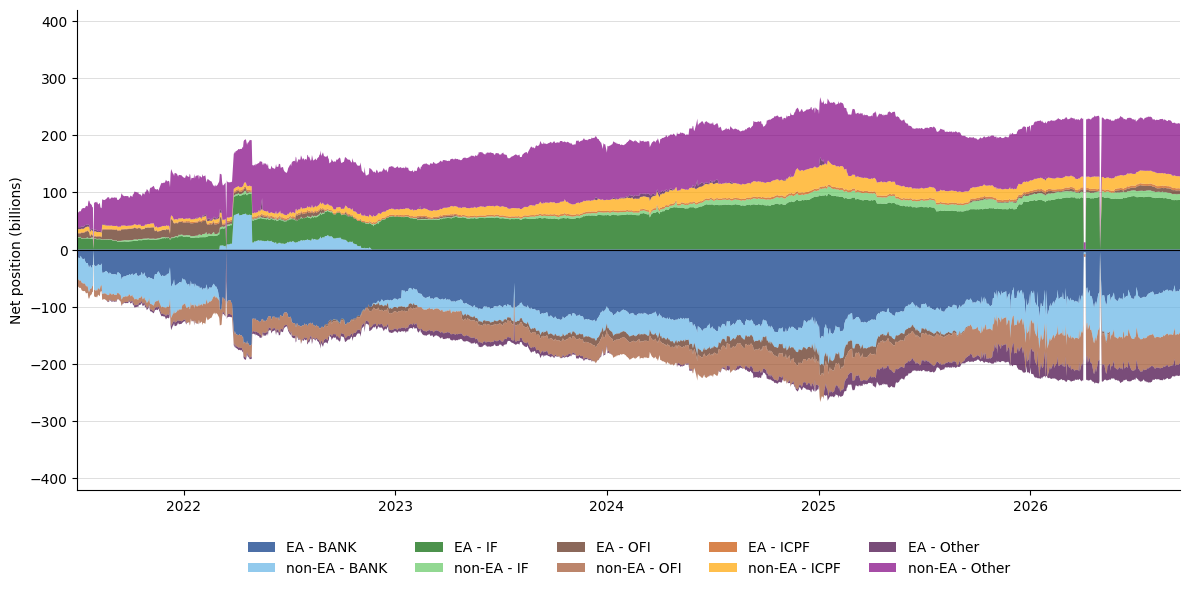

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Stacked area chart of net securities lending positions in US bonds by sector,
# same look as the German futures sector chart in the slides: positives stack
# upwards, negatives downwards, one hue per sector, EA darker and non-EA lighter

df_plot = df_us.copy()
df_plot['reference_period'] = pd.to_datetime(df_plot['reference_period'])
df_plot['net_bn'] = df_plot['net_position'] / 1e9

order = ['EA - BANK', 'non-EA - BANK',
         'EA - IF', 'non-EA - IF',
         'EA - OFI', 'non-EA - OFI',
         'EA - ICPF', 'non-EA - ICPF',
         'EA - Other', 'non-EA - Other']
colors = {'EA - BANK': (0/255, 50/255, 130/255),      'non-EA - BANK': (100/255, 180/255, 230/255),
          'EA - IF': (0/255, 100/255, 0/255),         'non-EA - IF': (100/255, 200/255, 100/255),
          'EA - OFI': (90/255, 40/255, 20/255),       'non-EA - OFI': (160/255, 82/255, 45/255),
          'EA - ICPF': (200/255, 80/255, 0/255),      'non-EA - ICPF': (255/255, 165/255, 0/255),
          'EA - Other': (64/255, 0/255, 64/255),      'non-EA - Other': (128/255, 0/255, 128/255)}

pivot = (df_plot.pivot_table(index='reference_period', columns='ea_sector',
                             values='net_bn', aggfunc='sum', fill_value=0)
                .reindex(columns=order, fill_value=0)
                .sort_index())

pos = pivot.clip(lower=0)
neg = pivot.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(pos.index, pos.T.values, labels=order, colors=[colors[s] for s in order], alpha=0.7, linewidth=0)
ax.stackplot(neg.index, neg.T.values, colors=[colors[s] for s in order], alpha=0.7, linewidth=0)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_ylabel('Net position (billions)')
ax.set_xlabel('')
ax.set_ylim(-420,420)
ax.margins(x=0)
ax.grid(axis='y', color='0.85', linewidth=0.6)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False)

plt.tight_layout()
plt.savefig('Figures\\net_sec_lending_US_sectors.png', dpi=270, bbox_inches='tight')
plt.show()

In [27]:
query = f"""

WITH sector_volumes AS (
  -- Total Lending by mapped EA-Sector
  SELECT 
    reference_period,
    (CASE WHEN lender_country IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
          THEN 'EA' ELSE 'non-EA' END) || ' - ' || 
    (CASE lender_sector 
          WHEN 'S122' THEN 'BANK'
          WHEN 'S124' THEN 'IF'
          WHEN 'S125' THEN 'OFI'
          WHEN 'S128' THEN 'ICPF'
          WHEN 'S129' THEN 'ICPF'
          ELSE 'Other' END) AS ea_sector,
    SUM(loan_value_eur_clean) AS lending_vol,
    0 AS borrowing_vol
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_sl
  WHERE isin IN {isin_unique}
  AND LEFT(isin, 2) != 'US'
  AND reference_period >= '2021-07-01'
  GROUP BY reference_period, ea_sector

  UNION ALL

  -- Total Borrowing by mapped EA-Sector
  SELECT 
    reference_period,
    (CASE WHEN borrower_country IN ('AT','BE','HR','CY','EE','FI','FR','DE','GR','IE','IT','LV','LT','LU','MT','NL','PT','SK','SI','ES') 
          THEN 'EA' ELSE 'non-EA' END) || ' - ' || 
    (CASE borrower_sector 
          WHEN 'S122' THEN 'BANK'
          WHEN 'S124' THEN 'IF'
          WHEN 'S125' THEN 'OFI'
          WHEN 'S128' THEN 'ICPF'
          WHEN 'S129' THEN 'ICPF'
          ELSE 'Other' END) AS ea_sector,
    0 AS lending_vol,
    SUM(loan_value_eur_clean) AS borrowing_vol
  FROM xlab_ecb_prj_sftds_cb_common.hermesf_sl
  WHERE isin IN {isin_unique}
    AND LEFT(isin, 2) != 'US'
    AND reference_period >= '2021-07-01'
  GROUP BY reference_period, ea_sector
)

SELECT 
  reference_period,
  ea_sector,
  SUM(lending_vol) AS total_lending,
  SUM(borrowing_vol) AS total_borrowing,
  SUM(lending_vol) - SUM(borrowing_vol) AS net_position
FROM sector_volumes
GROUP BY reference_period, ea_sector
ORDER BY reference_period, ea_sector;

"""
df_ea = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_19484\1022008531.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ea = pd.read_sql_query(query, cnxn)


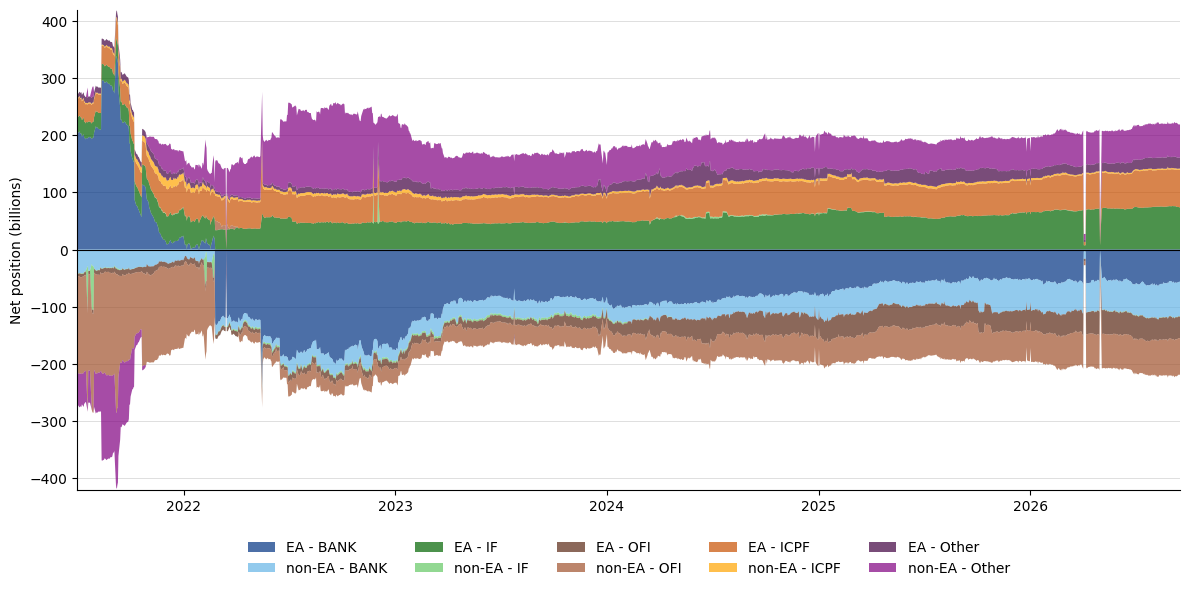

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Stacked area chart of net securities lending positions in US bonds by sector,
# same look as the German futures sector chart in the slides: positives stack
# upwards, negatives downwards, one hue per sector, EA darker and non-EA lighter

df_plot = df_ea.copy()
df_plot['reference_period'] = pd.to_datetime(df_plot['reference_period'])
df_plot['net_bn'] = df_plot['net_position'] / 1e9

order = ['EA - BANK', 'non-EA - BANK',
         'EA - IF', 'non-EA - IF',
         'EA - OFI', 'non-EA - OFI',
         'EA - ICPF', 'non-EA - ICPF',
         'EA - Other', 'non-EA - Other']
colors = {'EA - BANK': (0/255, 50/255, 130/255),      'non-EA - BANK': (100/255, 180/255, 230/255),
          'EA - IF': (0/255, 100/255, 0/255),         'non-EA - IF': (100/255, 200/255, 100/255),
          'EA - OFI': (90/255, 40/255, 20/255),       'non-EA - OFI': (160/255, 82/255, 45/255),
          'EA - ICPF': (200/255, 80/255, 0/255),      'non-EA - ICPF': (255/255, 165/255, 0/255),
          'EA - Other': (64/255, 0/255, 64/255),      'non-EA - Other': (128/255, 0/255, 128/255)}

pivot = (df_plot.pivot_table(index='reference_period', columns='ea_sector',
                             values='net_bn', aggfunc='sum', fill_value=0)
                .reindex(columns=order, fill_value=0)
                .sort_index())

pos = pivot.clip(lower=0)
neg = pivot.clip(upper=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(pos.index, pos.T.values, labels=order, colors=[colors[s] for s in order], alpha=0.7, linewidth=0)
ax.stackplot(neg.index, neg.T.values, colors=[colors[s] for s in order], alpha=0.7, linewidth=0)
ax.axhline(0, color='black', linewidth=0.8)

ax.set_ylabel('Net position (billions)')
ax.set_xlabel('')
ax.set_ylim(-420,420)
ax.margins(x=0)
ax.grid(axis='y', color='0.85', linewidth=0.6)
ax.set_axisbelow(True)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False)

plt.tight_layout()
plt.savefig('Figures\\net_sec_lending_EA_sectors.png', dpi=270, bbox_inches='tight')
plt.show()